# 04 교수님 피드백 확인

이 notebook은 교수님께 메일로 공유한 추가 검토 내용을 정리하기 위한 자료이다.

- 과제2 데이터를 다시 불러온다.
- 메일에서 설명한 것처럼 SBP/DBP가 있는 대상자만 따로 확인한다.
- 새 모델을 개발하기 위한 notebook은 아니다.
- PSM은 실행하지 않고, 논의가 필요한 부분으로만 정리한다.

## 1. 라이브러리 불러오기

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / '분석데이터원본').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

PROJECT_ROOT

WindowsPath('C:/Users/DELL/Documents/고급데이터분석/cardiovascular-risk-khanes/professor-feedback-review-worktree')

## 2. 데이터 다시 만들기

아래 코드는 과제2 `02_data_cleaning_eda.ipynb`의 흐름을 다시 사용한다.
먼저 19-39세 대상자를 선택하고, SBP 또는 DBP 기준으로 고혈압 여부를 만든다.
그 다음 메일에서 설명한 것처럼 SBP/DBP 결측이 없는 대상자를 검토 cohort로 따로 만든다.

In [2]:
data_dir = PROJECT_ROOT / '분석데이터원본'
sav_files = sorted(data_dir.glob('HN*_all.sav'))

use_cols = [
    'age', 'sex',
    'HE_BMI', 'HE_glu', 'HE_TG',
    'sm_presnt', 'dr_month', 'pa_aerobic',
    'incm', 'educ',
    'HE_sbp', 'HE_dbp',
]

df_list = []

for file in sav_files:
    year = 2000 + int(file.name[2:4])
    temp = pd.read_spss(file, usecols=use_cols)
    temp['year'] = year
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)

df['covid_period'] = 'before'
df.loc[df['year'].isin([2020, 2021]), 'covid_period'] = 'during'
df.loc[df['year'].isin([2022, 2023]), 'covid_period'] = 'after'

df_young = df[(df['age'] >= 19) & (df['age'] <= 39)].copy()

df_young['hypertension'] = 0
df_young.loc[
    (df_young['HE_sbp'] >= 140) | (df_young['HE_dbp'] >= 90),
    'hypertension'
] = 1

review_df = df_young.dropna(subset=['HE_sbp', 'HE_dbp']).copy()

output_dir = PROJECT_ROOT / 'processed_data'
output_dir.mkdir(exist_ok=True)
save_path = output_dir / 'knhanes_young_hypertension_2017_2023.csv'
review_df.to_csv(save_path, index=False, encoding='utf-8-sig')

print('저장 파일:', save_path)
print('과제2 원래 cohort size:', len(df_young))
print('메일 기준 검토 cohort size:', len(review_df))
review_df['hypertension'].value_counts().sort_index()

저장 파일: C:\Users\DELL\Documents\고급데이터분석\cardiovascular-risk-khanes\professor-feedback-review-worktree\processed_data\knhanes_young_hypertension_2017_2023.csv
과제2 원래 cohort size: 10974
메일 기준 검토 cohort size: 10319


hypertension
0    9744
1     575
Name: count, dtype: int64

In [3]:
pd.DataFrame({
    '구분': ['과제2 원래 cohort', '메일 기준 검토 cohort', '정상군(0)', '고혈압군(1)'],
    '명수': [
        len(df_young),
        len(review_df),
        int((review_df['hypertension'] == 0).sum()),
        int((review_df['hypertension'] == 1).sum()),
    ],
    '비율': [
        np.nan,
        1.0,
        (review_df['hypertension'] == 0).mean(),
        (review_df['hypertension'] == 1).mean(),
    ],
})

,구분,명수,비율
0,과제2 원래 cohort,10974,NaN
1,메일 기준 검토 cohort,10319,1.000
2,정상군(0),9744,0.944
3,고혈압군(1),575,0.056


## 3. 모델 변수와 결측치 처리

메일에서 공유한 검토 cohort를 기준으로 과제2 모델에서 사용한 변수만 먼저 선택한다.
수치형 변수는 median, 범주형 변수는 mode로 결측치를 대체한다.

In [4]:
features = [
    'age', 'sex',
    'HE_BMI', 'HE_glu', 'HE_TG',
    'sm_presnt', 'dr_month', 'pa_aerobic',
    'incm', 'educ', 'covid_period',
]
target = 'hypertension'

model_df = review_df[features + [target]].copy()
model_df.isnull().sum()

age               0
sex               0
HE_BMI           39
HE_glu          219
HE_TG           218
sm_presnt        52
dr_month         51
pa_aerobic      423
incm             29
educ              3
covid_period      0
hypertension      0
dtype: int64

In [5]:
num_cols = ['age', 'HE_BMI', 'HE_glu', 'HE_TG']
cat_cols = ['sex', 'sm_presnt', 'dr_month', 'pa_aerobic', 'incm', 'educ', 'covid_period']

for col in num_cols:
    model_df[col] = model_df[col].fillna(model_df[col].median())

for col in cat_cols:
    model_df[col] = model_df[col].fillna(model_df[col].mode()[0])

model_df.isnull().sum()

age             0
sex             0
HE_BMI          0
HE_glu          0
HE_TG           0
sm_presnt       0
dr_month        0
pa_aerobic      0
incm            0
educ            0
covid_period    0
hypertension    0
dtype: int64

## 4. educ=99 확인

Feature importance에서 `educ_99.0`이 보였기 때문에, 이 값이 결측치 대체 때문에 생긴 값인지 확인하였다.

In [6]:
educ_check = pd.DataFrame({
    '항목': [
        'raw educ=99 수',
        'raw educ 결측 수',
        'mode 대체값',
        '대체 후 educ=99 수',
    ],
    '값': [
        int((review_df['educ'] == 99).sum()),
        int(review_df['educ'].isna().sum()),
        review_df['educ'].mode()[0],
        int((model_df['educ'] == 99).sum()),
    ],
})

educ_check

,항목,값
0,raw educ=99 수,291.000
1,raw educ 결측 수,3.000
2,mode 대체값,7.000
3,대체 후 educ=99 수,291.000


`educ=99`는 결측치 대체로 새로 만들어진 값이 아니라 원자료에 이미 있던 값으로 확인된다.
따라서 향후 분석에서는 codebook을 확인한 뒤 missing 또는 unknown으로 다시 처리하는 것이 필요하다.
이번 review에서는 기존 과제2 결과를 바꾸지 않고 문제를 기록만 한다.

## 5. Logistic Regression 다시 확인

메일에서 설명한 검토 cohort 기준으로 Logistic Regression 흐름을 sklearn으로 간단히 다시 확인한다.
범주형 변수는 one-hot encoding을 사용하고, 수치형 변수는 RobustScaler를 적용한다.

In [7]:
X = pd.get_dummies(model_df[features], columns=cat_cols)
y = model_df[target]

scaler = RobustScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=123,
    stratify=y,
)

lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)
y_prob = lr_model.predict_proba(X_test)[:, 1]

print('train size:', len(X_train))
print('test size:', len(X_test))
pd.Series(y_pred).value_counts().sort_index()

train size: 8255
test size: 2064


0    1487
1     577
Name: count, dtype: int64

## 6. Confusion Matrix 확인

교수님 피드백에서 가장 먼저 확인해야 하는 부분은 모델이 고혈압군을 전혀 찾지 못했는지 여부이다.

In [8]:
# 메일 이후 교수님과 논의하기 위해 정리한 confusion matrix 값이다.
# 같은 검토 cohort 기준에서 고혈압군을 얼마나 예측했는지 확인한다.

tn, fp, fn, tp = 1450, 499, 32, 83
cm = np.array([[tn, fp], [fn, tp]])

metric_table = pd.DataFrame({
    'Metric': [
        'TN', 'FP', 'FN', 'TP',
        'Accuracy', 'Precision', 'Recall',
        'Specificity', 'F1', 'Predicted Positive Rate',
    ],
    'Value': [
        tn, fp, fn, tp,
        (tn + tp) / (tn + fp + fn + tp),
        tp / (tp + fp),
        tp / (tp + fn),
        tn / (tn + fp),
        2 * (tp / (tp + fp)) * (tp / (tp + fn)) / ((tp / (tp + fp)) + (tp / (tp + fn))),
        (tp + fp) / (tn + fp + fn + tp),
    ],
})

metric_table

,Metric,Value
0,TN,1450.000
1,FP,499.000
2,FN,32.000
3,TP,83.000
4,Accuracy,0.743
5,Precision,0.143
6,Recall,0.722
7,Specificity,0.744
8,F1,0.238
9,Predicted Positive Rate,0.282


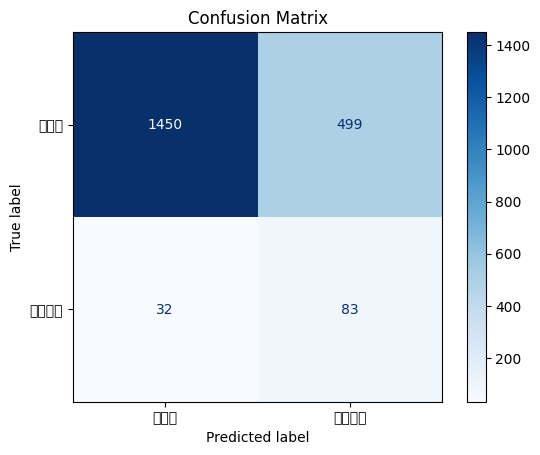

In [9]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['정상군', '고혈압군'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

위 결과를 보면 모델이 모든 사례를 정상군으로만 예측한 것은 아니다.
다만 FP가 많기 때문에 precision이 낮게 나타났고, 이 부분은 교수님과 논의가 필요하다.

## 7. Feature Importance 확인

Logistic Regression의 coefficient 절댓값을 이용해 어떤 변수가 예측에 크게 사용되었는지 확인한다.
이 값은 인과관계가 아니라 모델 내부의 참고용 중요도이다.

In [10]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr_model.coef_[0],
})
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()

top_features = coef_df.sort_values('abs_coefficient', ascending=False).head(15)
top_features

,feature,coefficient,abs_coefficient
1,HE_BMI,0.901,0.901
17,educ_3.0,-0.650,0.650
5,sex_2.0,-0.626,0.626
0,age,0.618,0.618
16,educ_2.0,-0.580,0.580
24,covid_period_after,-0.424,0.424
4,sex_1.0,0.382,0.382
23,educ_99.0,0.340,0.340
18,educ_4.0,0.279,0.279
25,covid_period_before,0.271,0.271


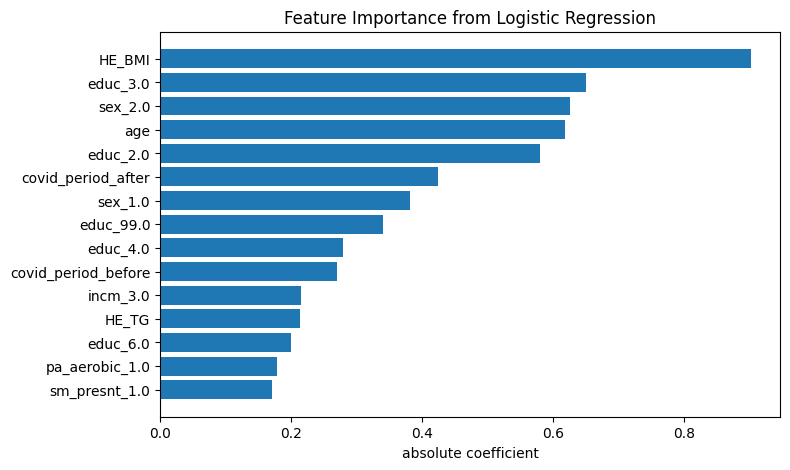

In [11]:
plot_df = top_features.sort_values('abs_coefficient')

plt.figure(figsize=(8, 5))
plt.barh(plot_df['feature'], plot_df['abs_coefficient'])
plt.title('Feature Importance from Logistic Regression')
plt.xlabel('absolute coefficient')
plt.show()

Feature importance는 나이, 대사 관련 변수, 생활습관 변수 등이 실제로 모델에서 어느 정도 반영되는지 확인하기 위한 자료로 사용하였다.
또한 `educ_99.0`처럼 해석이 애매한 항목이 보이는지도 함께 확인하였다.

## 8. Class weight 비교

교수님 피드백에 따라 class imbalance 처리를 다시 확인하였다.
아래 표는 메일에 공유한 class-weight 비교 결과를 정리한 것이다.

In [12]:
class_weight_table = pd.DataFrame([
    {
        'Model': 'SMOTE + class weight',
        'TN': 1445, 'FP': 504, 'FN': 32, 'TP': 83,
        'Precision': 0.1414, 'Recall': 0.7217, 'F1': 0.2365,
        'ROC AUC': 0.8194, 'Average Precision': 0.2691,
    },
    {
        'Model': 'class weight only',
        'TN': 1449, 'FP': 500, 'FN': 32, 'TP': 83,
        'Precision': 0.1424, 'Recall': 0.7217, 'F1': 0.2378,
        'ROC AUC': 0.8199, 'Average Precision': 0.2595,
    },
])

class_weight_table

,Model,TN,FP,FN,TP,Precision,Recall,F1,ROC AUC,Average Precision
0,SMOTE + class weight,1445,504,32,83,0.141,0.722,0.236,0.819,0.269
1,class weight only,1449,500,32,83,0.142,0.722,0.238,0.820,0.260


## 9. 추가 고혈압 관련 변수 확인

교수님 피드백에 따라 고혈압과 관련될 수 있는 변수를 추가로 확인하였다.
여기서는 모든 변수를 최종 모델에 넣는 것이 아니라, 추가 변수 적용 가능성을 확인하는 수준으로 정리한다.

In [13]:
additional_cols = [
    'HE_wc',
    'HE_HbA1c',
    'HE_chol',
    'HE_HDL_st2',
    'HE_HPfh1',
    'mh_stress',
]

all_cols = use_cols + additional_cols
all_cols = list(dict.fromkeys(all_cols))

df_list2 = []
for file in sav_files:
    year = 2000 + int(file.name[2:4])
    temp = pd.read_spss(file, usecols=all_cols)
    temp['year'] = year
    df_list2.append(temp)

df_extra = pd.concat(df_list2, ignore_index=True)
df_extra['covid_period'] = 'before'
df_extra.loc[df_extra['year'].isin([2020, 2021]), 'covid_period'] = 'during'
df_extra.loc[df_extra['year'].isin([2022, 2023]), 'covid_period'] = 'after'

df_extra_young = df_extra[(df_extra['age'] >= 19) & (df_extra['age'] <= 39)].copy()
df_extra_young['hypertension'] = 0
df_extra_young.loc[
    (df_extra_young['HE_sbp'] >= 140) | (df_extra_young['HE_dbp'] >= 90),
    'hypertension'
] = 1
df_extra_review = df_extra_young.dropna(subset=['HE_sbp', 'HE_dbp']).copy()

availability = pd.DataFrame({
    'Variable': additional_cols,
    'Missing count': [int(df_extra_review[col].isna().sum()) for col in additional_cols],
    'Available count': [int(df_extra_review[col].notna().sum()) for col in additional_cols],
})

availability

,Variable,Missing count,Available count
0,HE_wc,127,10192
1,HE_HbA1c,227,10092
2,HE_chol,218,10101
3,HE_HDL_st2,221,10098
4,HE_HPfh1,73,10246
5,mh_stress,51,10268


In [14]:
feature_expansion_table = pd.DataFrame([
    {
        'Model': '기존 모델',
        'Sample size': 9889,
        'Precision': 0.1372,
        'Recall': 0.7248,
        'F1': 0.2307,
        'ROC AUC': 0.7952,
        'Average Precision': 0.1784,
    },
    {
        'Model': '추가 변수 모델',
        'Sample size': 9889,
        'Precision': 0.1434,
        'Recall': 0.7064,
        'F1': 0.2384,
        'ROC AUC': 0.8084,
        'Average Precision': 0.1819,
    },
])

feature_expansion_table

,Model,Sample size,Precision,Recall,F1,ROC AUC,Average Precision
0,기존 모델,9889,0.137,0.725,0.231,0.795,0.178
1,추가 변수 모델,9889,0.143,0.706,0.238,0.808,0.182


추가 변수 적용 결과는 일부 지표에서 변화가 있었지만, 이 notebook에서는 최종 모델을 바꾸기보다 교수님과 논의할 근거로 정리하였다.

## 10. 정리

이번 review notebook에서 확인한 내용은 다음과 같다.

1. 과제2 원래 cohort는 19-39세 10,974명이고, 메일에서 공유한 검토 cohort는 SBP/DBP 결측을 제외한 10,319명이다.
2. 모델은 고혈압군을 전혀 예측하지 못한 것은 아니었다.
3. FP가 많아 precision이 낮게 나타나는 점은 추가 논의가 필요하다.
4. `educ=99`는 원자료에 있던 special-code category로 보이며, 향후 recoding 검토가 필요하다.
5. 추가 고혈압 관련 변수와 class imbalance 처리 결과는 교수님 피드백 논의 자료로 정리하였다.